# 正态分布于概率密度函数（PDF）

## 连续随机变量 vs 离散随机变量

1. 离散 ：取有限或可数。    连续 : 取无限不可数，落在某个区间
   
   关键区别：连续随机变量在任意单点的概率为0，只能讨论区间概率

## 概率密度函数（PDF）

1. f(x) 不是概率，而是该点附近的 “密度”。区间 [a,b] 的概率 = f_a^bf(x)dx（曲线下面积）

## 正态分布（高斯分布）

· 一般公式：
$$
f(x) = \frac{1}{\sqrt{2\pi}\sigma} e^{-\frac{(x-\mu)^2}{2\sigma^2}}
$$

· 标准正态分布 N(0,1):
$$
\varphi(x) = \frac{1}{\sqrt{2\pi}} e^{-\frac{x^2}{2}}
$$

### 正态分布参数释义
$$f(x) = \frac{1}{\sqrt{2\pi}\sigma} e^{-\frac{(x-\mu)^2}{2\sigma^2}}$$

| 参数 | 中文名称 | 作用说明 |
| :--- | :--- | :--- |
| $x$ | 随机变量 | 样本实际取值 |
| $\mu$ | 均值/数学期望 | 决定曲线中心位置 |
| $\sigma$ | 标准差 | 决定曲线宽窄平缓程度 |
| $\sigma^2$ | 方差 | 数据离散程度 |
| $\pi$ | 圆周率 | 固定常数 |
| $e$ | 自然常数 | 固定常数 |
| $f(x)$ | 概率密度 | 对应取值的密度大小 |

### 核心口诀
- $\mu$ 控左右位置
- $\sigma$ 控高矮胖瘦

## 经验法则（68-95-99.7法则）

· $\mu$ +- $\sigma$ ：约为68%的数据

· $\mu$ +- 2 $\sigma$ ：约为95%的数据

· $\mu$ +- 3 $\sigma$ ： 约为99.7%的数据

## z-score（标准化）

· z=(x - $\mu$)/$\sigma$

· 作用 ：将不同单位的正态分布转换为标准正态分布，方便比较

# Numpy 正态分布常用函数

1. 生成正态分布随机函数：普通正态分布： np.random.normal(loc=均值,scale=标准差,size=形状) （loc对应 $\mu$ 。scale 对应 $\sigma$）
                        标准正态分布： np.random.randn(维度)

2. 概率密度函数（公式对应正态分布那条钟形曲线，纵坐标就是 pdf 值）

from scipy.stats import norm
norm.pdf(x,loc,scale)

3. 累积分布概率 cdf （小于等于这个数的总概率）（算区间内的面积，总概率）

from scipy.stats import norm
norm.cdf(x,loc,scale)

· x : 要计算概率的那个数值（比如求P(X<=1)，这里x=1）

4. from scipy.stats import norm

· scipy ： Python科学计算库，专门做统计、数学运算

· stats : scipy 里的统计学模块

· norm : 专门代表正态分布这个工具

· 意思是： 从 scipy 库的统计模块里，把正态分布工具拿过来直接用

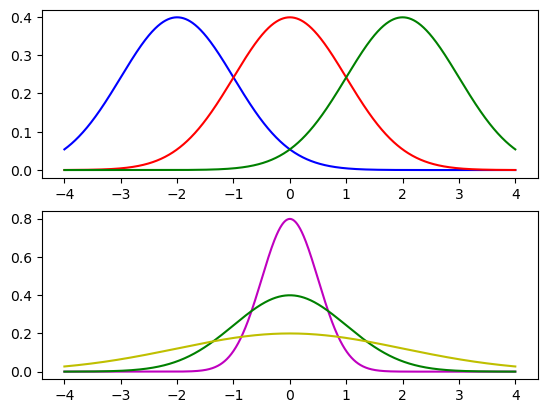

In [23]:
## 练习1：可视化不同参数的正态分布

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 生成连续的 x 轴采样点（不是随机数，是从 -4 到 4 的均匀序列）
x=np.linspace(-4,4,1000)

# 第一个子图的数据
mu1,sigma1=-2,1
mu2,sigma2=0,1
mu3,sigma3=2,1
pdf1=norm.pdf(x,loc=mu1,scale=sigma1)
pdf2=norm.pdf(x,loc=mu2,scale=sigma2)
pdf3=norm.pdf(x,loc=mu3,scale=sigma3)

# 第二个子图的数据
mu4,sigma4=0,0.5
mu5,sigma5=0,1
mu6,sigma6=0,2
pdf4=norm.pdf(x,loc=mu4,scale=sigma4)
pdf5=norm.pdf(x,loc=mu5,scale=sigma5)
pdf6=norm.pdf(x,loc=mu6,scale=sigma6)

#第一个子图
plt.figure()
plt.subplot(2,1,1)
plt.plot(x,pdf1,'b-')
plt.plot(x,pdf2,'r-')
plt.plot(x,pdf3,'g-')

#第二个子图
plt.subplot(2,1,2)
plt.plot(x,pdf4,'m-')
plt.plot(x,pdf5,'g-')
plt.plot(x,pdf6,'y-')
plt.show()


In [ ]:
# 练习2：验证经验法则

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

x=np.random.normal(loc=100,scale=15,size=10000)
sigma_mu_sigma=norm.cdf(115,loc=100,scale=15)-norm.cdf(85,loc=100,scale=15)
sigma2_mu_sigma2=norm.cdf(130,loc=100,scale=15)-norm.cdf(70,loc=100,scale=15)
sigma3_mu_sigma3=norm.cdf(145,loc=100,scale=15)-norm.cdf(55,loc=100,scale=15)
print(f"mu -+ sigma 的范围比例：{sigma_mu_sigma:.4f}")
print(f"mu -+ 2sigma 的范围比例：{sigma2_mu_sigma2:.4f}")
print(f"mu -+ 3sigma 的范围比例：{sigma3_mu_sigma3:.4f}")



In [ ]:
# 异常值检测

import numpy as np

data = [120, 122, 119, 121, 123, 180, 118, 121]
mu=np.mean(data)
sigma=np.std(data)
print(f"该组数据的均值为{mu:.2f}，标准差为{sigma:.2f}")
# 计算每一个数据点的z-score：
z_score=[]
unnormal_value=[]
for i in data:
    z=(i-mu)/sigma
    if abs(z)>2:
        z_score.append(z)
        unnormal_value.append(i)
print(f"当阈值为2时，异常值为{unnormal_value}，其z-score为{z_score}")


标准化后的体重分布标准差更大（理论上应都接近1）


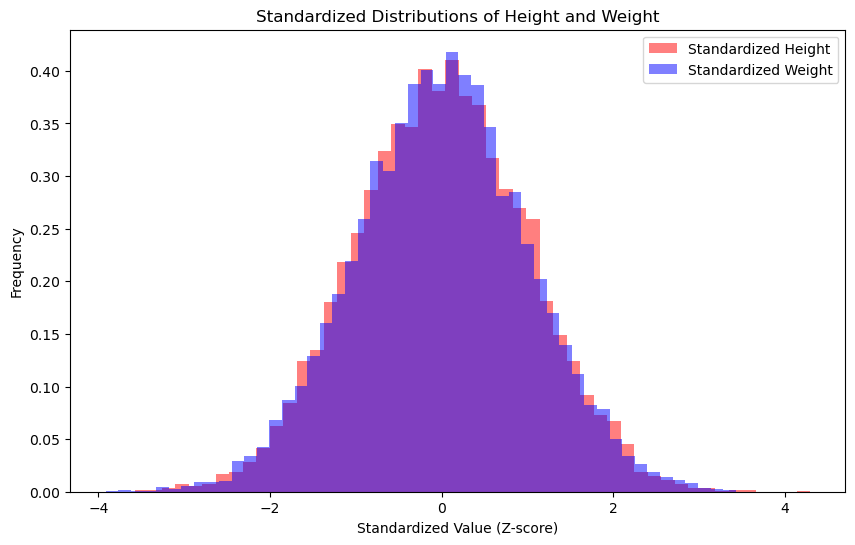

标准化后两组数据分布几乎重合，说明消除了量纲影响，使不同单位的特征可比较。


In [24]:
## 练习4：标准化的必要性

import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

height=np.random.normal(loc=170,scale=10,size=10000)
weight=np.random.normal(loc=70,scale=15,size=10000)

mu1,mu2=np.mean(height),np.mean(weight)
sigma1,sigma2=np.std(height),np.std(weight)
z_h=(height-mu1)/sigma1
z_w=(weight-mu2)/sigma2
std_z_h = np.std(z_h)
std_z_w = np.std(z_w)
if std_z_h > std_z_w:
    print("标准化后的身高分布标准差更大（理论上应都接近1）")
elif std_z_h == std_z_w:
    print("两者标准化后相等（理论上标准差都为1）")
else:
    print("标准化后的体重分布标准差更大（理论上应都接近1）")
# 绘制直方图（正确用法）
plt.figure(figsize=(10, 6))
plt.hist(z_h, bins=50, alpha=0.5, color='r', label='Standardized Height',density=True)
plt.hist(z_w, bins=50, alpha=0.5, color='b', label='Standardized Weight',density=True)
plt.legend()
plt.title("Standardized Distributions of Height and Weight")
plt.xlabel("Standardized Value (Z-score)")
plt.ylabel("Frequency")

plt.show()
print("标准化后两组数据分布几乎重合，说明消除了量纲影响，使不同单位的特征可比较。")

# plt.hist() 与 plt.bar() 详细用法及对比
## 一、核心区别对照表
| 对比项 | plt.hist() 直方图 | plt.bar() 柱状图 |
| ---- | ---- | ---- |
| 核心用途 | 统计**连续数值数据**的分布、频次 | 对比**离散分类数据**的数值大小 |
| X轴含义 | 自动划分的数值区间（bins 分箱） | 手动指定的分类/坐标位置 |
| 柱子间距 | 柱子紧密相连，无空隙 | 柱子之间默认存在空隙 |
| 适用场景 | 身高、体重、成绩、时间等连续数据 | 班级、品类、月份、组别等分类数据 |

---

## 二、plt.hist() 直方图
### 1. 语法格式
plt.hist(x, bins=None, color=None, alpha=1, edgecolor=None, label=None, density=False)

### 2. 常用参数说明
 
-  x ：必填，传入一维连续数据集

-  bins ：分箱数/区间边界。传整数=自动均分区间；传列表=自定义区间

-  color ：柱子填充颜色

-  alpha ：透明度，取值  0~1 ，越小越透明

-  edgecolor ：柱子边框颜色，区分相邻区间

-  label ：图例名称，搭配  plt.legend()  使用

-  density ：布尔值， True  转为概率密度，总面积为1

## 三、plt.bar() 柱状图
### 1.语法格式
plt.bar(x, height, width=0.8, color=None, alpha=1, label=None)

### 2. 常用参数说明
 
-  x ：必填，柱子在X轴上的位置/分类标签（离散值）

-  height ：必填，每根柱子的高度（对应分类的数值）

-  width ：柱子宽度，默认  0.8 

-  color ：柱子填充颜色

-  alpha ：透明度，取值  0~1 

-  label ：图例名称